## Figure 4: Burst rates in LMFG and RMTG differentiate WM performance

In [1]:
# Adjust the path to the root data folder containing dataset_description.json, sourcedata/, etc.
DATA_PATH = "/Volumes/External/dataset/"
SUBJECTS = [f"sub-P{k}" for k in range(1, 8)]

In [2]:
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# Adjust the path to the location of burst_toolbox
import sys
sys.path.append("/Users/vladimiromelyusik/burst_toolbox/src")

from burst_toolbox.dsp import compute_power
from burst_toolbox.stats import cluster_test_2samp
from burst_toolbox.bursts import detect_bursts

## Data processing

In [3]:
# Read the data
data = utils.read_openneuro(path = DATA_PATH, subjects = SUBJECTS)
data["sc"] = data["subject"] + "_" + data["channel"].astype(str)

data.head()

Extracting EDF parameters from /Volumes/External/dataset/sub-P1/ieeg/sub-P1_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P2/ieeg/sub-P2_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P3/ieeg/sub-P3_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P4/ieeg/sub-P4_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P5/ieeg/sub-P5_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P6/ieeg/sub-P6_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters fr

,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,LFP_6,LFP_7,LFP_8,LFP_9,...,LFP_6495,LFP_6496,LFP_6497,subject,region,channel,modulated,trial_idx,n_correct,sc
0,32.028687,34.012360,35.965515,38.284886,42.282750,46.219577,48.905165,48.416876,47.501335,48.447395,...,28.000305,22.201877,19.211109,sub-P1,LMTG,23,1,1,0,sub-P1_23
1,-3.463798,-2.029450,-3.189136,-2.944991,-1.266499,-1.510643,-2.975509,-5.050736,-7.461662,-8.285649,...,15.274281,16.739147,17.746242,sub-P1,LMTG,23,1,3,0,sub-P1_23
2,-107.316701,-102.952621,-97.398337,-92.912184,-89.311055,-83.176928,-77.317464,-74.113069,-72.892348,-71.580072,...,-29.953460,-26.565957,-22.079805,sub-P1,LMTG,23,1,5,2,sub-P1_23
3,18.722820,19.394217,21.347372,24.551766,24.887465,23.544671,21.774624,19.607843,16.433967,13.076982,...,-25.528344,-26.199741,-27.908751,sub-P1,LMTG,23,1,8,3,sub-P1_23
4,-20.767529,-22.873274,-25.223163,-26.169223,-23.300526,-18.326085,-16.159304,-14.450294,-9.201190,-1.144427,...,-50.827802,-52.079042,-53.177691,sub-P1,LMTG,23,1,10,3,sub-P1_23


In [4]:
# Compute power and detect high gamma and beta bursts
processed_data = []

for region in ["LMFG", "RMTG"]:
    for freq_band in ["beta", "high_gamma"]:
        for subject_channel in data[data["region"] == region]["sc"].unique():
            subject, channel = subject_channel.split("_")
            channel = int(channel)
            
            # Compute power
            channel_data = data[(data["subject"] == subject) & (data["channel"] == channel)]
            power = compute_power(LFP = channel_data[utils.LFP_COLS].to_numpy(), freq_band = utils.FREQ_BANDS[freq_band])

            # Detect bursts
            bursts = detect_bursts(
                power = power,
                reference_period = np.array([1, 1000]),
                min_dur_ms = 3 * 1000 / np.mean(utils.FREQ_BANDS[freq_band])
            )

            composite = pd.DataFrame(np.hstack((power, bursts)), columns = utils.POWER_COLS + utils.BURST_COLS)
            composite["subject"] = subject
            composite["region"] = region
            composite["channel"] = channel
            composite["freq_band"] = freq_band
            composite["trial_idx"] = channel_data["trial_idx"].to_numpy()
            composite["modulated"] = channel_data["modulated"].to_numpy()
            composite["n_correct"] = channel_data["n_correct"].to_numpy()

            processed_data.append(composite)

processed_data = pd.concat(processed_data, axis = 0, ignore_index = True)
processed_data.head()

,power_0,power_1,power_2,power_3,power_4,power_5,power_6,power_7,power_8,power_9,...,bursts_6495,bursts_6496,bursts_6497,subject,region,channel,freq_band,trial_idx,modulated,n_correct
0,6.544030,6.646046,7.782911,8.412919,9.411584,10.192759,11.193510,12.118448,13.185223,14.266943,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,1,0,0
1,22.869988,21.754875,25.859255,27.594122,31.066299,33.319479,36.367352,38.748520,41.384938,43.700259,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,5,0,2
2,18.133333,13.194748,14.400935,14.721481,15.737993,16.884758,17.844060,19.368527,20.313834,22.074690,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,8,0,3
3,9.327621,9.027730,10.030496,10.360521,11.160145,11.586686,12.289968,12.757604,13.408420,13.907587,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,10,0,3
4,12.486770,11.636928,13.984695,15.061250,17.071779,18.609779,20.457306,22.228373,23.953539,25.845476,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,12,0,3


## Baseline-subtracted burst rates (Fig. 4a)

**Note:** takes ~1 min. 40 sec. to run due to cluster testing.

/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:200: RuntimeWarning: Mean of empty slice
  sample1_window = np.nanmean(sample1[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:201: RuntimeWarning: Mean of empty slice
  sample2_window = np.nanmean(sample2[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:200: RuntimeWarning: Mean of empty slice
  sample1_window = np.nanmean(sample1[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:201: RuntimeWarning: Mean of empty slice
  sample2_window = np.nanmean(sample2[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:200: RuntimeWarning: Mean of empty slice
  sample1_window = np.nanmean(sample1[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py

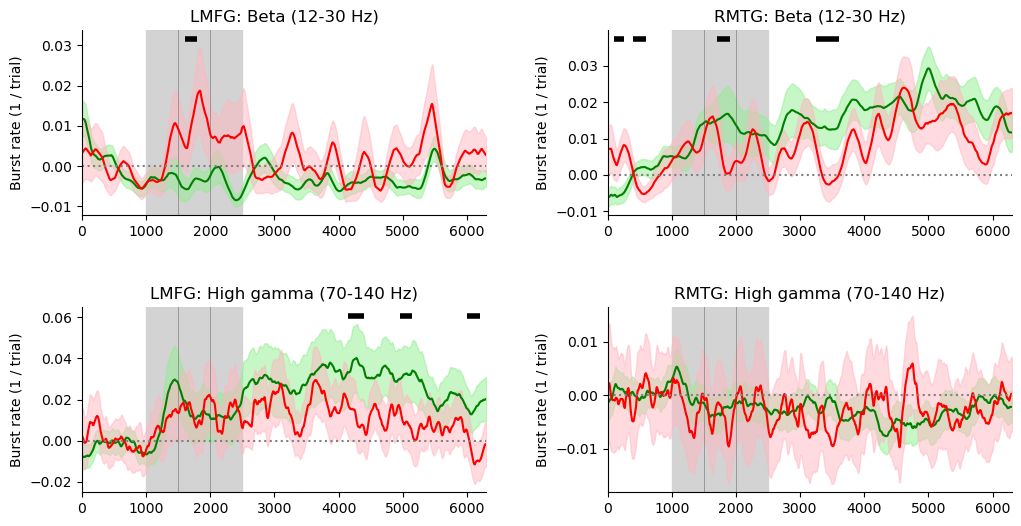

In [5]:
fig, ax = plt.subplots(2, 2, figsize = (12, 6))

for col_id, region in enumerate(["LMFG", "RMTG"]):
    for row_id, freq_band in enumerate(["beta", "high_gamma"]):

        ca = ax[row_id, col_id]
        ca.axvspan(1000, 2500, color = 'lightgray')
        ca.axvline(1500, color = 'gray', linewidth = 0.5)
        ca.axvline(2000, color = 'gray', linewidth = 0.5)

        test_samples = []
        for perf in ["correct", "incorrect"]:

            burst_rate = processed_data[
                (processed_data["region"] == region) &
                (processed_data["freq_band"] == freq_band) &
                (processed_data["modulated"] == 1)
            ]

            if perf == "correct":
                burst_rate = burst_rate[burst_rate["n_correct"] == 3]
            else:
                burst_rate = burst_rate[burst_rate["n_correct"] <= 1]

            # Compute per-channel burst rate
            burst_rate = burst_rate[utils.BURST_COLS + ["subject", "channel"]]
            burst_rate = burst_rate.groupby(["subject", "channel"]).agg(lambda x: np.nanmean(x, axis = 0)).reset_index()
            burst_rate = burst_rate.sort_values(by = ["subject", "channel"])[utils.BURST_COLS].to_numpy()
            n_channels = len(burst_rate)

            # Baseline-correct (peformance plots have a different baseline!)
            burst_rate = burst_rate - np.nanmean(burst_rate[:, 200 : 800], axis = 1, keepdims = True)
            burst_rate = burst_rate[:, :utils.CUTOFF]
            test_samples.append(burst_rate)

            # Compute stats
            avg_burst_rate = np.nanmean(burst_rate, axis = 0)
            sem_burst_rate = np.nanstd(burst_rate, axis = 0) / np.sqrt(n_channels)

            ca.plot(
                np.arange(utils.CUTOFF),
                uniform_filter1d(avg_burst_rate, 200),
                color = utils.PLOTTING[perf]["color"]
            )
            ca.fill_between(
                np.arange(utils.CUTOFF),
                uniform_filter1d(avg_burst_rate - sem_burst_rate, 200),
                uniform_filter1d(avg_burst_rate + sem_burst_rate, 200),
                color = utils.PLOTTING[perf]["fillcolor"],
                alpha = 0.5
            )

        # Cluster-test
        step = 50
        win_range = np.arange(0, len(utils.BURST_COLS), step)
        clusters = cluster_test_2samp(
            sample1 = test_samples[0],
            sample2 = test_samples[1],
            win_range = win_range,
            win_size = 200,
            stat_q_threshold = 0.95 # Was 0.95 when working on the paper, now using a tighter threshold
        )

        if len(clusters) > 0:
            yval = ca.get_ylim()[1]
            for tstat_id, period in enumerate(win_range):
                if (period < 100) or (period >= utils.CUTOFF - 100): continue
                if clusters[tstat_id] == 0: continue
                ca.hlines(yval, period, period + step, color = 'black', linewidth = 4)

        title = f"{region}: {utils.PLOTTING[freq_band]['title']}"
        ca.set_title(title)

        ca.set_ylabel("Burst rate (1 / trial)")
        ca.axhline(0, ls = "dotted", color = "gray")
        ca.set_xlim(0, utils.CUTOFF)
        ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(hspace = 0.5, wspace = 0.3)

## Bar plots of burst rates during 3 periods (Fig. 4b)

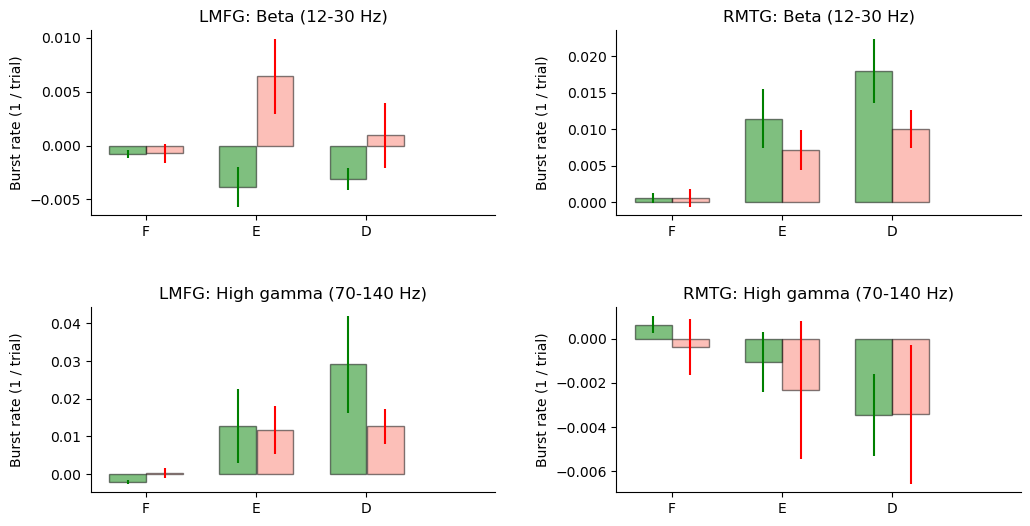

In [6]:
fig, ax = plt.subplots(2, 2, figsize = (12, 6))

for col_id, region in enumerate(["LMFG", "RMTG"]):
    for row_id, freq_band in enumerate(["beta", "high_gamma"]):

        ca = ax[row_id, col_id]

        for perf in ["correct", "incorrect"]:

            burst_rate = processed_data[
                (processed_data["region"] == region) &
                (processed_data["freq_band"] == freq_band) &
                (processed_data["modulated"] == 1)
            ]

            if perf == "correct":
                burst_rate = burst_rate[burst_rate["n_correct"] == 3]
                offset = 0
            else:
                burst_rate = burst_rate[burst_rate["n_correct"] <= 1]
                offset = 0.101

            # Compute per-channel burst rate
            burst_rate = burst_rate[utils.BURST_COLS + ["subject", "channel"]]
            burst_rate = burst_rate.groupby(["subject", "channel"]).agg(lambda x: np.nanmean(x, axis = 0)).reset_index()
            burst_rate = burst_rate.sort_values(by = ["subject", "channel"])[utils.BURST_COLS].to_numpy()
            n_channels = len(burst_rate)

            # Baseline-correct (peformance plots have a different baseline!)
            burst_rate = burst_rate - np.nanmean(burst_rate[:, 200 : 800], axis = 1, keepdims = True)
            burst_rate = burst_rate[:, :utils.CUTOFF]

            # Compute stats
            for period_bounds, period_label in zip([(100, 1000), (1000, 2500), (2500, 6000)], ["F", "E", "D"]):
                period_avg_burst_rate = np.nanmean(burst_rate[:, period_bounds[0] : period_bounds[1]], axis = 1)
                avg_burst_rate = np.nanmean(period_avg_burst_rate)
                sem_burst_rate = np.nanstd(period_avg_burst_rate) / np.sqrt(n_channels) # Paper: np.sqrt(2 * n_channels) here but not in testing

                ca.bar(
                    offset, 
                    avg_burst_rate, 
                    width = 0.1,
                    color = "salmon" if perf == "incorrect" else utils.PLOTTING[perf]["color"], # salmon looks better on barplots
                    alpha = 0.5, 
                    edgecolor = 'black', 
                    yerr = sem_burst_rate, 
                    ecolor = utils.PLOTTING[perf]["color"]
                )
                offset += 0.3

        ca.set_xticks([0.05, 0.35, 0.65], labels = ["F", "E", "D"])

        title = f"{region}: {utils.PLOTTING[freq_band]['title']}"
        ca.set_title(title)

        ca.set_ylabel("Burst rate (1 / trial)")
        ca.set_xlim(-0.1, 1)
        ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(hspace = 0.5, wspace = 0.3)